<a href="https://colab.research.google.com/github/iestleija/4808-Programacion/blob/Unidad3/Unidad3/Practices/266229_02_semana11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

** Regresión lineal con datos categóricos: Costos, Localidades y Salarios**

# Maestría en Inteligencia Artificial y Analítica de Datos

## Programación para Analítica Descriptiva y Predictiva - Marzo 2025
## Práctica: Regresión con Datos Categóricos
---


## Datos del Estudiante

*   Apellidos y Nombre: Ismael Estrada Leija
*   Matrícula: 266229

---


📌 Objetivos de la Práctica:
Al finalizar esta práctica, los estudiantes serán capaces de:

- Codificar variables categóricas usando one-hot encoding con K-1 para problemas de regresión
- Realizar AED
- Construir un modelo de regresión con variables dummy
- Interpretar los resultados de los coeficientes
- Analizar los resultados de los errores residuales
- Calcular el desempeño del modelo de regresión.

Problema: Se podría argumentar que el salario está relacionado con el costo de la educación. Por lo tanto, para analizar este argumentos veremos qué sucede cuando usamos las variables independientes cost y location.

In [19]:
from google.colab import drive
drive.mount('/content/drive')
def print_bold(msg):
    print("\n\033[1m" + msg + "\033[0m")
path_to_file = "/content/drive/MyDrive/4808-programacion/semana11/Practica02/college.csv"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# 1. Carga de datos

Carga el conjunto de datos college.csv, que está en campus virtual, en un dataframe. Elige de este conjunto las columnas salary (variable dependiente), cost(variable independiente - numérica) y location (variable independiente categórica).

Realiza lo siguiente:

*   Convierte si es necesario la variable location a tipo de dato categórico
*   Usa la instrucción describe() en las variables salary y cost
* Cuenta la cantidad de datos que hay por categoría en location
* Convierte la variable location usando one-hot encoding



In [20]:
import pandas as pd

# Cargar el conjunto de datos
df = pd.read_csv(path_to_file, usecols=['salary', 'cost', 'location'])

# Mostrar las primeras filas para verificar la carga
print_bold("DataFrame inicial:")
display(df.head())



DataFrame inicial:


,salary,cost,location
0,119000,189300,NE
1,121000,189600,NE
2,123000,188400,NE
3,123000,188700,NE
4,110000,194200,NE


In [21]:
# Convierte la variable 'location' a tipo de dato categórico
df['location'] = df['location'].astype('category')

print("Tipo de dato de 'location' después de la conversión:")
print(df['location'].dtype)


Tipo de dato de 'location' después de la conversión:
category


In [22]:
# Usa la instrucción describe() en las variables salary y cost
print_bold("Descripción estadística de 'salary':")
display(df['salary'].describe())

print_bold("Descripción estadística de 'cost':")
display(df['cost'].describe())



Descripción estadística de 'salary':


,salary
count,85.000000
mean,95898.823529
std,11937.121912
min,74900.000000
25%,87100.000000
50%,93200.000000
75%,105000.000000
max,123000.000000



Descripción estadística de 'cost':


,cost
count,85.000000
mean,142434.470588
std,53913.064578
min,18260.000000
25%,84670.000000
50%,169200.000000
75%,188700.000000
max,227300.000000


In [23]:
# Cuenta la cantidad de datos que hay por categoría en location
print_bold("Conteo de datos por categoría en 'location':")
display(df['location'].value_counts())



Conteo de datos por categoría en 'location':


,count
location,
NE,25
W,21
S,20
MW,19


In [24]:
# Convierte la variable location usando one-hot encoding (con K-1 para evitar la multicolinealidad)
df_encoded = pd.get_dummies(df, columns=['location'], drop_first=True)

print_bold("DataFrame después de aplicar one-hot encoding a 'location':")
display(df_encoded.head())



DataFrame después de aplicar one-hot encoding a 'location':


,salary,cost,location_NE,location_S,location_W
0,119000,189300,True,False,False
1,121000,189600,True,False,False
2,123000,188400,True,False,False
3,123000,188700,True,False,False
4,110000,194200,True,False,False


# 2. Análisis Exploratorio de los Datos

Realiza un análisis exploratorio de los datos y discute lo que observas en cada gráfica.


*   Crea un histograma de la columna salary. Discute lo que observas
* Crea un diagrama de dispersión de salary vs cost, considerando lo siguiente: para cada punto elegirás un color que represente la localidad en la que está el salario y el costo de la educación. Por lo tanto el diagrama de dispersión debería tener puntos en 4 colores distintos. Discute lo que observas
* Emplea un boxplot para saber si hay diferencias en los costos según la ubicación, es decir, con boxplot deberás analizar la distribución de cost por localidad. Discute lo que observas




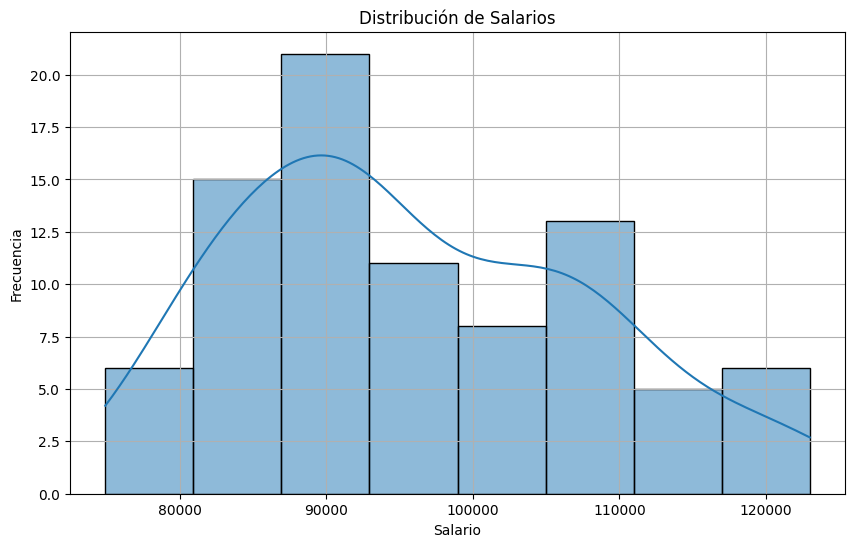

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

# 2.1 Histograma de la columna salary
plt.figure(figsize=(10, 6))
sns.histplot(df['salary'], kde=True)
plt.title('Distribución de Salarios')
plt.xlabel('Salario')
plt.ylabel('Frecuencia')
plt.grid(True)
plt.show()


### Análisis del Histograma de Salarios

En la gráfica generada, se puede observar que la distribución de salarios es ligeramente sesgada a la izquierda, con la mayoría de los salarios concentrados entre 80 y 110 mil, y un rango que va de aproximadamente 74 hasta 123 mil.

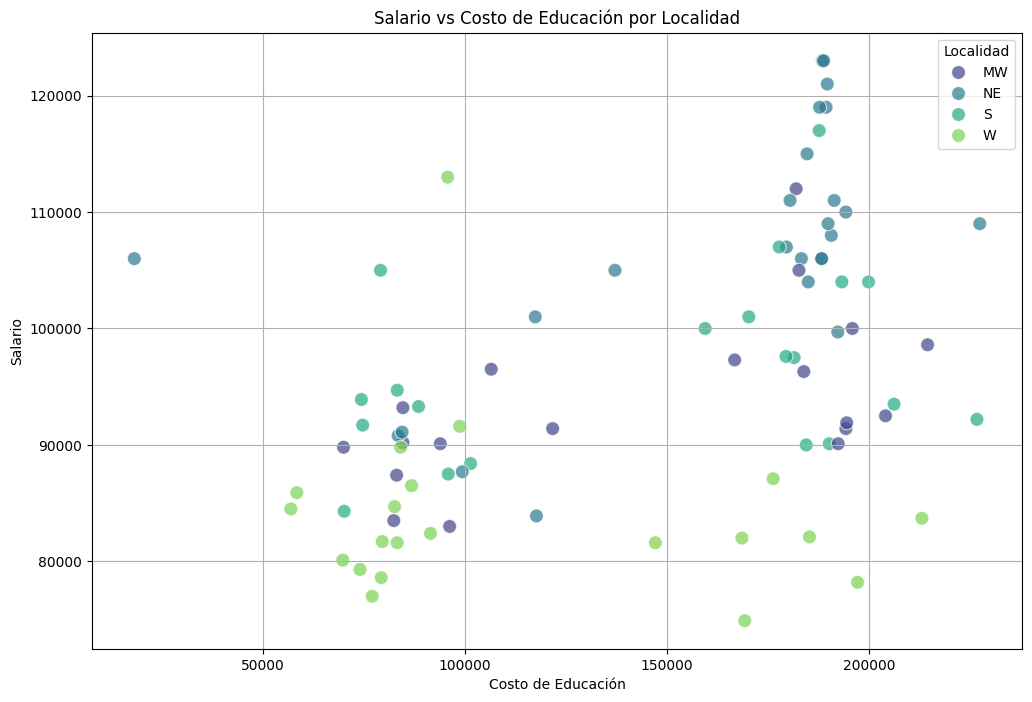

In [32]:
# 2.2 Diagrama de dispersión de salary vs cost, coloreado por location
plt.figure(figsize=(12, 8))
sns.scatterplot(data=df, x='cost', y='salary', hue='location', palette='viridis', s=100, alpha=0.7)
plt.title('Salario vs Costo de Educación por Localidad')
plt.xlabel('Costo de Educación')
plt.ylabel('Salario')
plt.grid(True)
plt.legend(title='Localidad')
plt.show()

### Análisis del Diagrama de Dispersión (Salario vs. Costo por Localidad)

El diagrama de dispersión de `salary` vs `cost`, coloreado por `location`, nos permite visualizar la relación entre estas tres variables simultáneamente. Al observar esta gráfica, podemos buscar los siguientes patrones:

* **MidWest(MW):** Cuenta con una relación coherente entre salarios y costo de la educación y con salarios entre 85 y 110 mil y costo de los 60 y 210 mil aproximadamente
* **NorthEast(NE):** Se asocia regularmente a salarios y costos de la educación altos con algunos valores atípicos a la baja.
* **South (S):** Atiende un rango alto de salarios y costos, con rangos entre 85 y 110 mil y 70 y 200 mil respectivamente con pocos valores atípicos en todas direcciones.
* **West(W):**Abarca un rango amplio de costos desde aproximadamente 55 hasta 220 mil y los salarios estan regularmente por debajo de 90 mil con un par de excepciones.

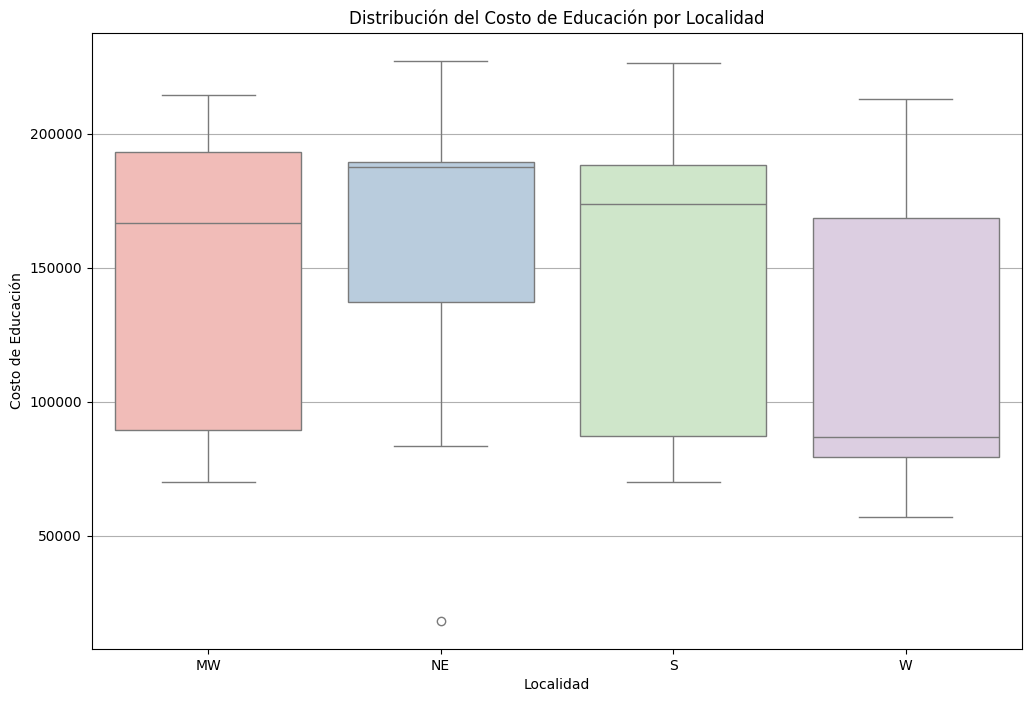

In [33]:
# 2.3 Boxplot de cost por localidad
plt.figure(figsize=(12, 8))
sns.boxplot(data=df, x='location', y='cost', hue='location', palette='Pastel1', legend=False)
plt.title('Distribución del Costo de Educación por Localidad')
plt.xlabel('Localidad')
plt.ylabel('Costo de Educación')
plt.grid(axis='y')
plt.show()

### Análisis del Boxplot (Distribución del Costo de Educación por Localidad)

El boxplot de `cost` por `location` permite visualizar la distribución del costo de la educación para cada una de las localidades. A partir de esta gráfica, podemos inferir:

*   La localidad **'NE' (Noreste)** tiene una mediana de costo de educación más alta en comparación con otras regiones, y su distribución parece estar más concentrada en rangos de costos elevados.
*   La localidad **'W' (Oeste)** muestra una mayor variabilidad en sus costos, con un rango intercuartílico más amplio y, posiblemente, la presencia de algunos valores atípicos que se desvían de la norma.
*   La localidad **'MW' (Medio Oeste)** parece tener costos de educación más bajos y una distribución más compacta.
*   La localidad **'S' (Sur)** podría tener una mediana similar a 'MW' pero con una ligera asimetría o algunos valores atípicos hacia arriba.

# 3. Construcción del modelo de regresión

- Construye el modelo de regresión usando los datos de salario, costo y location. Recuerda que esta última debe ser en su versión codificada con one-hot encoding.
- Imprime los coeficientes e interpreta qué significan cuando se sustituyen valores en costo, y location (versión codificada). Si no recuerdas cómo se hace esta interpretación consulta los videos.


In [39]:
import statsmodels.api as sm

# Definir las variables dependientes e independientes
Y = df_encoded['salary']
X = df_encoded[['cost', 'location_NE', 'location_S', 'location_W']]

# Convertir las columnas booleanas a enteros (0 o 1)
X = X.astype(int)

# Añadir una constante al modelo para el intercepto
X = sm.add_constant(X)

# Construir el modelo de regresión lineal
model = sm.OLS(Y, X)

# Ajustar el modelo
results = model.fit()

# Extraer los coeficientes (parámetros theta) del modelo
theta_parameters = results.params

print_bold("Parámetros Theta (Coeficientes) del Modelo de Regresión:")
display(theta_parameters)

print_bold("La ecuación de regresión se puede construir como:")
print(f"Salario = {theta_parameters['const']:.2f} + {theta_parameters['cost']:.2f} * Costo + \
       {theta_parameters['location_NE']:.2f} * location_NE + \
       {theta_parameters['location_S']:.2f} * location_S + \
       {theta_parameters['location_W']:.2f} * location_W")



Parámetros Theta (Coeficientes) del Modelo de Regresión:


,0
const,84988.716228
cost,0.060518
location_NE,12032.819692
location_S,2800.345026
location_W,-7721.420103



La ecuación de regresión se puede construir como:
Salario = 84988.72 + 0.06 * Costo +        12032.82 * location_NE +        2800.35 * location_S +        -7721.42 * location_W


### Interpretación de los Coeficientes (Parámetros Theta)

La ecuación de regresión obtenida es:

`Salario = 84988.72 + 0.06 * Costo + 12032.82 * location_NE + 2800.35 * location_S + -7721.42 * location_W`

A partir de los parámetros (coeficientes) del modelo:

*   **`const` (84988.72)**: Este es el intercepto del modelo. Representa el salario estimado (en dólares) cuando el `cost` de la educación es 0 y la localidad es la categoría de referencia. Dado que `location_MW` fue la categoría eliminada mediante `drop_first=True`, este valor de 84988.72 se interpreta como el salario base estimado para la región **MidWest (MW)** cuando el costo es cero.

*   **`cost` (0.06)**: Por cada unidad de aumento en el `cost` de la educación, el `salary` estimado aumenta en 0.06 dólares, manteniendo la localidad constante. Esto sugiere una relación positiva, aunque aparentemente pequeña, entre el costo de la educación y el salario.

*   **`location_NE` (12032.82)**: Este coeficiente indica que, en promedio, un individuo en la región **NorthEast (NE)** tiene un salario estimado 12032.82 dólares más alto que un individuo en la región de referencia (MW), manteniendo constante el `cost` de la educación.

*   **`location_S` (2800.35)**: Similarmente, un individuo en la región **South (S)** tiene un salario estimado 2800.35 dólares más alto que un individuo en la región de referencia (MW), manteniendo constante el `cost` de la educación.

*   **`location_W` (-7721.42)**: Para un individuo en la región **West (W)**, el salario estimado es 7721.42 dólares **menor** que un individuo en la región de referencia (MW), manteniendo constante el `cost` de la educación. El signo negativo indica que, en promedio, los salarios en el Oeste son más bajos en comparación con el Medio Oeste.

# 4. Análisis de Residuos

- Construyen una visualización de predicciones (salario estimado) vs valores reales (salario real).
- Crea una gráfica de los errores residuales. Discute lo que observas

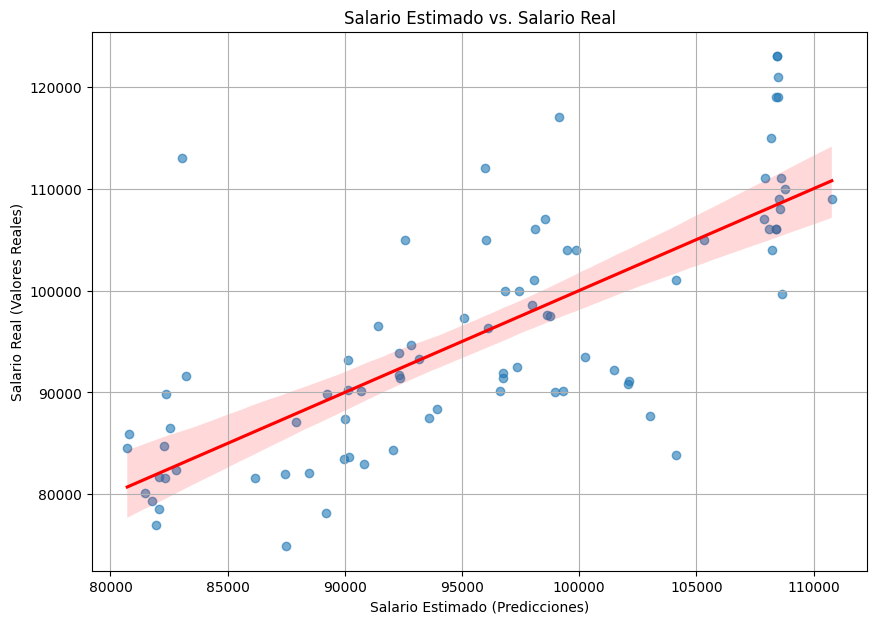

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calcular las predicciones del modelo
predictions = results.predict(X)

# 4.1 Visualización de predicciones vs. valores reales
plt.figure(figsize=(10, 7))
sns.regplot(x=predictions, y=Y, scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
plt.xlabel('Salario Estimado (Predicciones)')
plt.ylabel('Salario Real (Valores Reales)')
plt.title('Salario Estimado vs. Salario Real')
plt.grid(True)
plt.show()

### Análisis de la gráfica Salario Estimado vs. Salario Real

Esta gráfica de dispersión muestra el `Salario Estimado` (eje X) frente al `Salario Real` (eje Y), con una línea roja que representa la predicción ideal (donde `Salario Estimado = Salario Real`).

Observamos que la mayoría de los puntos se agrupan alrededor de la línea roja, lo que indica que el modelo tiene una capacidad predictiva razonable. La dispersión de los puntos alrededor de esta línea nos muestra la magnitud de los errores del modelo: cuanto más cerca estén los puntos de la línea, mejores son las predicciones.

No se aprecian patrones sistemáticos en la dispersión, lo que sugiere que el modelo no tiene un sesgo evidente. Sin embargo, hay algunos puntos que se desvían más de la línea, lo que representa predicciones con mayores errores para esos casos específicos.

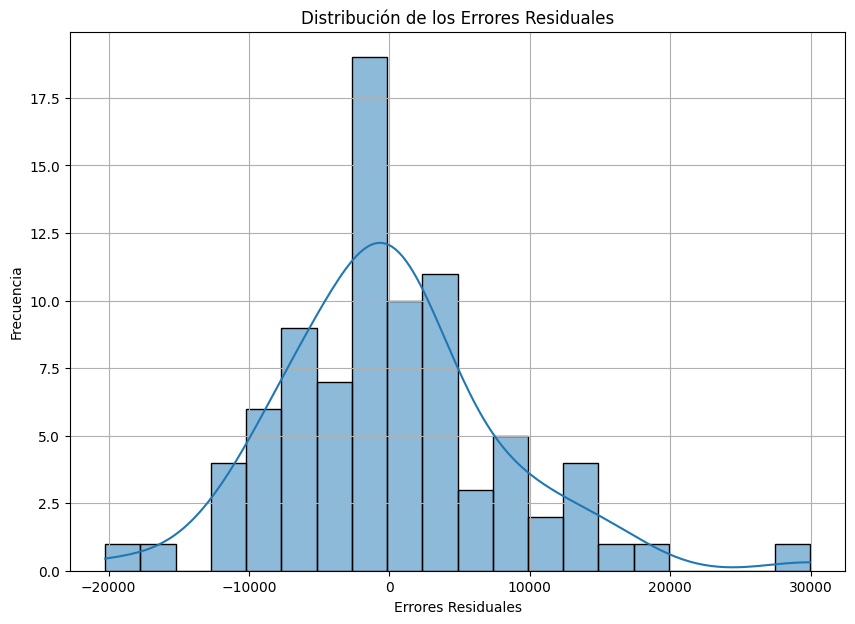

In [35]:
# Calcular los errores residuales
residuals = Y - predictions

# 4.2 Gráfica de los errores residuales
plt.figure(figsize=(10, 7))
sns.histplot(residuals, kde=True, bins=20)
plt.xlabel('Errores Residuales')
plt.ylabel('Frecuencia')
plt.title('Distribución de los Errores Residuales')
plt.grid(True)
plt.show()

### Análisis de la Distribución de los Errores Residuales

Al observar el histograma de los errores residuales, se aprecia que la distribución tiende a ser simétrica y está centrada alrededor de cero. La mayoría de los errores se agrupan cerca de la media, y la frecuencia disminuye a medida que los valores residuales se alejan del cero. La forma general del histograma se asemeja a una campana, sugiriendo una distribución normal.

# 5. Evalúa el modelo

- Calcula el MSE del modelo construido. Recuerda que usas el propio conjunto de datos (No hablamos nada de entrenamiento y test).
- Calcula el R² Score

Discute estos resultados obtenidos.

In [40]:
from sklearn.metrics import mean_squared_error, r2_score

# 5.1 Calcular el Error Cuadrático Medio (MSE)
mse = mean_squared_error(Y, predictions)
print(f"Error Cuadrático Medio (MSE): {mse:.2f}")

Error Cuadrático Medio (MSE): 60480269.15


In [41]:
# 5.2 Calcular el R² Score
r_squared = results.rsquared
print(f"R² Score: {r_squared:.4f}")

R² Score: 0.5705


### Análisis de los Resultados del Modelo (MSE y R² Score)

*   **Error Cuadrático Medio (MSE)**: El MSE de `60480269.15` representa el promedio de los cuadrados de los errores entre los salarios reales y los salarios predichos por el modelo. Un valor de MSE más bajo indica que el modelo tiene predicciones más precisas. Para interpretar si este valor es 'bueno' o 'malo', se debe comparar con la escala de la variable dependiente (salario) y con MSEs de otros modelos o un valor de referencia.

*   **R² Score**: El valor de R² de `0.5705` indica la proporción de la varianza en la variable dependiente (salario) que puede ser explicada por las variables independientes (costo y localidad) en el modelo. Un R² de `0.5705` significa que el `57.05%` de la variabilidad en el salario es explicada por el modelo. Cuanto más cerca esté R² de 1, mejor será el ajuste del modelo a los datos. Un valor como este sugiere que el modelo tiene una capacidad explicativa razonable, pero aún hay una porción de la variabilidad del salario que no está siendo capturada por las variables incluidas.

# 6. Realiza un análisis de varianza con statsmodels

Consulta esto aquí https://www.statsmodels.org/dev/examples/notebooks/generated/variance_components.html

In [42]:
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm

# Para el análisis de varianza (ANOVA), es más conveniente usar statsmodels.formula.api
# y crear un modelo con la fórmula que incluya la variable categórica.
# Primero, asegurémonos de que 'location' en el DataFrame original (df) sea tratado como categórica para la fórmula.

df_anova = df.copy()
df_anova['location'] = df_anova['location'].astype('category')

# Construir el modelo lineal usando smf.ols con la fórmula
# C(location) indica a statsmodels que 'location' es una variable categórica
model_formula = 'salary ~ cost + C(location)'
model_anova = smf.ols(model_formula, data=df_anova).fit()

# Realizar el análisis de varianza
anova_results = anova_lm(model_anova)

print_bold("Resultados del Análisis de Varianza (ANOVA):")
display(anova_results)


Resultados del Análisis de Varianza (ANOVA):


,df,sum_sq,mean_sq,F,PR(>F)
C(location),3.0,6.040930e+09,2.013643e+09,31.335738,1.694998e-13
cost,1.0,7.878166e+08,7.878166e+08,12.259774,7.600629e-04
Residual,80.0,5.140823e+09,6.426029e+07,NaN,NaN


### Discusión del Análisis de Varianza (ANOVA)

El análisis ANOVA evalúa la significancia de las variables `cost` y `location` en la explicación del salario.

*   **`C(location)`**: Con un `PR(>F)` (p-value) extremadamente bajo (1.69e-13), la localidad es estadísticamente muy significativa. Esto indica que existen diferencias significativas en el salario promedio entre al menos algunas de las regiones.

*   **`cost`**: Con un `PR(>F)` (p-value) también muy bajo (7.60e-04), el costo de la educación es estadísticamente significativo. Sugiere que el costo de la educación tiene un impacto significativo en el salario.

En resumen, **tanto la localidad como el costo de la educación influyen de manera significativa en el salario**, según este análisis.